# Estatística descritiva univariada

## Tabela de distribuição de frequências e representações gráficas

As tabelas de distribuições de frequência podem ser utilizadas para representar a frequência de ocorrências de um conjunto de observações de variáveis qualitativas ou quantitativas.

No caso de variáveis qualitativas, a tabela representa a frequência de ocorrências de cada categoria da variável. Para as variáveis quantitativas discretas, a frequência de ocorrências é calculada para cada valor discreto da variável. Já os dados das variáveis contínuas são agrupados inicialmente em classes, e a partir daí são calculadas as
frequências de ocorrências para cada classe.

Uma tabela de distribuição de frequências usualmente comporta os seguintes cálculos:

- Frequência absoluta (*F<sub>i</sub>*): número de ocorrências de cada elemento *i* na amostra.
- Frequência relativa (*Fr<sub>i</sub>*): porcentagem relativa à frequência absoluta.
- Frequência acumulada (*F<sub>ac</sub>*): soma de todas as ocorrências até o elemento analisado.
- Frequência relativa acumulada (*Fr<sub>ac</sub>*}: porcentagem relativa à frequência acumulada (soma de todas as frequências relativas até o elemento analisado).

#### Exemplo 1

Um determinado hospital precisa de ao menos 60 doações de sangue por dia para manter seu estoque para transfusões. A seguinte base de dados apresenta o tipo sanguíneo para os doadores de um determinado dia. Utilizaremos tal base para construir uma tabela de distribuição de frequências.

In [3]:
import pandas as pd

DADOS = "../dados/blood_donors.csv"

df = pd.read_csv(DADOS)

df.head()

,donor_id,blood_type
0,1,a+
1,2,a+
2,3,a+
3,4,a+
4,5,a+


In [4]:
df.tail()

,donor_id,blood_type
55,56,o+
56,57,o+
57,58,o+
58,59,o-
59,60,o-


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   donor_id    60 non-null     int64
 1   blood_type  60 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [6]:
df.describe(exclude="number")

,blood_type
count,60
unique,8
top,o+
freq,32


In [7]:
df["blood_type"].value_counts()

blood_type
o+     32
a+     15
b+      6
a-      2
o-      2
b-      1
ab+     1
ab-     1
Name: count, dtype: int64

In [8]:
df["blood_type"].value_counts().sort_index()

blood_type
a+     15
a-      2
ab+     1
ab-     1
b+      6
b-      1
o+     32
o-      2
Name: count, dtype: int64

In [9]:
df_frq = pd.DataFrame()

df_frq["frequencia"] = df["blood_type"].value_counts().sort_index()
df_frq["frequencia_relativa"] = df["blood_type"].value_counts(normalize=True).sort_index()
df_frq["frequencia_acumulada"] = df_frq["frequencia"].cumsum()
df_frq["frequencia_relativa_acumulada"] = df_frq["frequencia_relativa"].cumsum()


df_frq


,frequencia,frequencia_relativa,frequencia_acumulada,frequencia_relativa_acumulada
blood_type,,,,
a+,15,0.250000,15,0.250000
a-,2,0.033333,17,0.283333
ab+,1,0.016667,18,0.300000
ab-,1,0.016667,19,0.316667
b+,6,0.100000,25,0.416667
b-,1,0.016667,26,0.433333
o+,32,0.533333,58,0.966667
o-,2,0.033333,60,1.000000


In [13]:
from auxiliares import tabela_distribuicao_frequencias

df_tabela = tabela_distribuicao_frequencias(df, "blood_type")

df_tabela

,frequencia,frequencia_relativa,frequencia_acumulada,frequencia_relativa_acumulada
blood_type,,,,
a+,15,0.250000,15,0.250000
a-,2,0.033333,17,0.283333
ab+,1,0.016667,18,0.300000
ab-,1,0.016667,19,0.316667
b+,6,0.100000,25,0.416667
b-,1,0.016667,26,0.433333
o+,32,0.533333,58,0.966667
o-,2,0.033333,60,1.000000


<Axes: xlabel='blood_type', ylabel='count'>

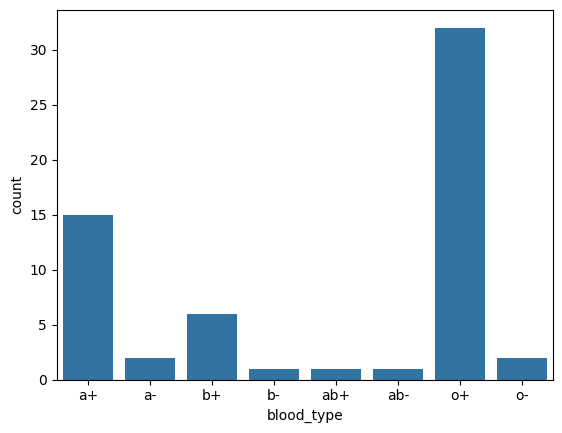

In [12]:
import seaborn as sns

sns.countplot(data=df, x="blood_type")

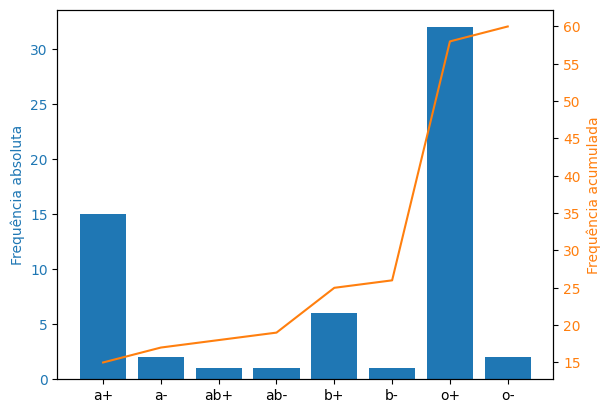

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots()

ax2 = ax.twinx()

ax.bar(df_tabela.index, df_tabela["frequencia"], color="C0")
ax2.plot(df_tabela.index, df_tabela["frequencia_acumulada"], color="C1")

ax.set_ylabel("Frequência absoluta", color="C0")
ax.tick_params(axis="y", labelcolor="C0")

ax2.set_ylabel("Frequência acumulada", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax2.yaxis.set_major_locator(mtick.MultipleLocator(base=5.0))

plt.show()

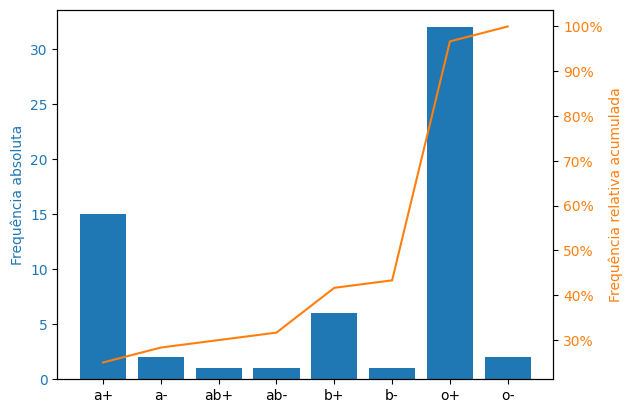

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots()

ax2 = ax.twinx()

ax.bar(df_tabela.index, df_tabela["frequencia"], color="C0")
ax2.plot(df_tabela.index, df_tabela["frequencia_relativa_acumulada"], color="C1")

ax.set_ylabel("Frequência absoluta", color="C0")
ax.tick_params(axis="y", labelcolor="C0")

ax2.set_ylabel("Frequência relativa acumulada", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.show()